# Imports and data/model preparation

In [1]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, PROJ_ROOT
from script.trainer import Trainer, EarlyStopping
from models.ResNet import ResNetClassifier
import torch
import torch.nn as nn
import torchmetrics.classification as metrics
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

2025-08-08 19:40:59.058 | INFO     | config:<module>:12 - PROJ_ROOT path is: /home/aislab/princisgh_map_completeness/map_completeness_estimation


## Visualize study parameters

In [2]:
study_file = PROJ_ROOT / 'studies/ResNetClassifier_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [3]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_batch_size,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.520301,2025-08-08 14:42:09.076500,2025-08-08 14:51:10.954722,0 days 00:09:01.878222,3.211409e-05,8,0.2,0.000004,2048,256.0,2,0.008187,0.537387,0.535568,COMPLETE
1,1,0.441425,2025-08-08 14:51:11.182334,2025-08-08 15:00:06.286744,0 days 00:08:55.104410,1.595107e-07,8,0.5,0.000292,1024,256.0,2,0.151378,0.441425,NaN,COMPLETE
2,2,0.366725,2025-08-08 15:00:06.556610,2025-08-08 15:07:13.724037,0 days 00:07:07.167427,1.175246e-06,128,0.3,0.000003,512,NaN,1,0.000557,0.369410,0.367351,COMPLETE
3,3,0.374202,2025-08-08 15:07:14.151946,2025-08-08 15:13:45.379805,0 days 00:06:31.227859,1.925051e-06,64,0.3,0.000008,2048,256.0,2,0.000233,0.362200,0.366468,COMPLETE
7,7,0.342934,2025-08-08 15:20:49.136008,2025-08-08 15:27:13.377820,0 days 00:06:24.241812,4.707859e-05,64,0.1,0.004593,128,NaN,1,0.000461,0.343463,0.340663,COMPLETE
14,14,0.434711,2025-08-08 15:40:55.300948,2025-08-08 15:47:58.741864,0 days 00:07:03.440916,1.123395e-06,16,0.5,0.000001,2048,NaN,1,0.000018,0.428967,NaN,COMPLETE
16,16,0.097670,2025-08-08 15:49:25.080711,2025-08-08 15:55:59.863328,0 days 00:06:34.782617,1.858065e-07,128,0.0,0.000002,512,2048.0,2,0.000194,0.176027,0.111066,COMPLETE
17,17,0.136083,2025-08-08 15:56:01.074676,2025-08-08 16:02:37.640223,0 days 00:06:36.565547,2.271012e-07,128,0.0,0.000075,512,NaN,1,0.000081,0.126515,NaN,COMPLETE
18,18,0.167900,2025-08-08 16:02:38.906929,2025-08-08 16:09:15.837222,0 days 00:06:36.930293,1.082704e-07,128,0.0,0.000042,512,NaN,1,0.000021,0.181535,0.167908,COMPLETE
19,19,0.105462,2025-08-08 16:09:17.195958,2025-08-08 16:15:51.793942,0 days 00:06:34.597984,4.504490e-07,128,0.0,0.000016,512,2048.0,2,0.001161,0.183205,0.130654,COMPLETE


In [4]:
params = study.best_params
print(params)

{'backbone_LR': 2.6717378541370503e-05, 'head_LR': 3.1137045297125165e-05, 'weight_decay': 0.0009858136146893386, 'batch_size': 32, 'head_layer_1': 256, 'num_layers': 2, 'head_layer_2': 2048, 'dropout': 0.0}


In [5]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [6]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [ ]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='classification', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='classification', )
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='classification', )

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'], num_workers=8)
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8, drop_last=True)

In [8]:
head_cfg = {
    'hidden_dims' : [256, 2048],
    'dropout_rate': params['dropout']
}
model = ResNetClassifier(img_size=224, head_cfg=head_cfg)

loss = torch.nn.CrossEntropyLoss()
ES = EarlyStopping(patience=5, restore_best_weights=True)
met = {
    "accuracy": metrics.BinaryAccuracy(),
    "precision": metrics.BinaryPrecision(),
    "recall": metrics.BinaryRecall(),
}

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 20

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss, met)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

### Compute CV loss

In [9]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=params['batch_size'], 
    task="classification", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/361 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 11/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.1902
5-fold CV loss: 0.2251
k-Fold CV loss: 0.22512


## Train classifier

In [10]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'classification', epochs=EPOCHS, early_stopping=ES)


Epoch 1/20:   0%|          | 0/451 [00:00<?, ?it/s]

[1/20] Train Loss: 0.2534


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

	accuracy: 0.9372
	precision: 0.9341
	recall: 0.9408
[1/20] Val Loss: 0.1695 



Epoch 2/20:   0%|          | 0/451 [00:00<?, ?it/s]

...

	accuracy: 0.9384
	precision: 0.9353
	recall: 0.9420
[12/20] Val Loss: 0.1516 



Epoch 13/20:   0%|          | 0/451 [00:00<?, ?it/s]

[13/20] Train Loss: 0.1079


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

	accuracy: 0.9290
	precision: 0.9275
	recall: 0.9309
[13/20] Val Loss: 0.1843 
Stopping training due to EarlyStopping


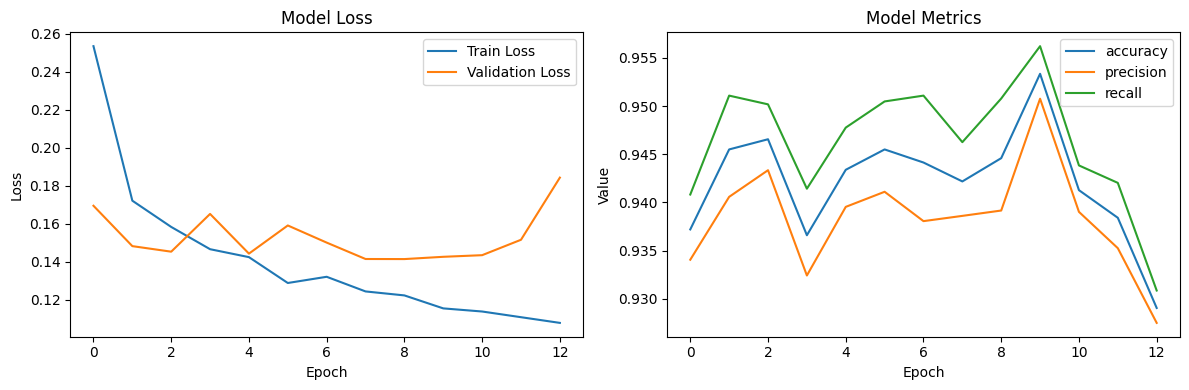

In [11]:
plot_history(trainer.history)

#### Validation Results

In [12]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR)

Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

	accuracy: 0.9422
	precision: 0.9386
	recall: 0.9463
Model ResNetClassifier_classification.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [14]:
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8, drop_last=True)
y_hat, y_true, test_loss = trainer.predict(test_loader)
print(f'Test Loss: {test_loss}')

Evaluation:   0%|          | 0/94 [00:00<?, ?it/s]

Test Loss: 0.20388667285442352


In [15]:
import torch.nn as nn
y_hat_np = nn.Softmax()(y_hat)[:,0].numpy()
y_true_np = y_true[:,0].numpy()

/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1751: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



In [16]:
def print_metrics(y_hat: np.ndarray, y_true: np.ndarray):
    print(classification_report(y_true, y_hat))
    print(f'Accuracy: {accuracy_score(y_true, y_hat)}')
    print(f'Precision: {precision_score(y_true, y_hat)}')
    print(f'Recall: {recall_score(y_true, y_hat)}')

    # confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_hat)
    #print cm values with labels
    cm_df = pd.DataFrame(cm, index=['Not Explored', 'Explored'], columns=['Not Explored', 'Explored'])
    print("Confusion Matrix DataFrame:")
    print(cm_df)

### Classification metrics for $\theta = 0.5$

In [17]:
y_hat_theta = (y_hat_np > 0.5).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91      1377
         1.0       0.97      0.87      0.92      1631

    accuracy                           0.91      3008
   macro avg       0.92      0.92      0.91      3008
weighted avg       0.92      0.91      0.91      3008

Accuracy: 0.914561170212766
Precision: 0.9744475138121547
Recall: 0.865113427345187
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1340        37
Explored               220      1411


### Classification metrics for $\theta = 0.8$

In [18]:
y_hat_theta = (y_hat_np > 0.8).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.79      0.99      0.88      1377
         1.0       0.99      0.77      0.87      1631

    accuracy                           0.87      3008
   macro avg       0.89      0.88      0.87      3008
weighted avg       0.89      0.87      0.87      3008

Accuracy: 0.8716755319148937
Precision: 0.9851909586905689
Recall: 0.7749846719803801
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1358        19
Explored               367      1264


### Visualize ROC & AUROC

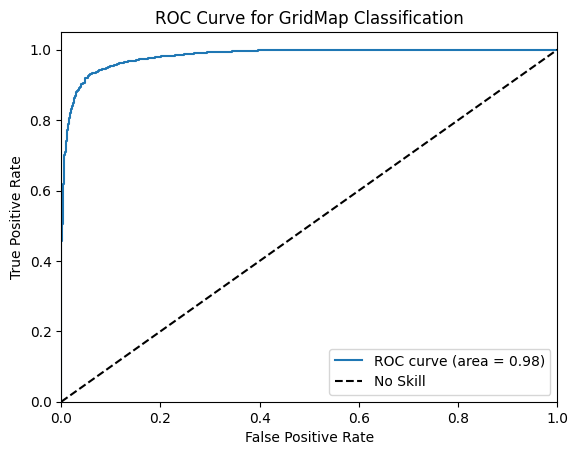

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true_np, y_hat_np)
roc_auc = auc(fpr, tpr)

plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for GridMap Classification')
plt.legend()
plt.show()